In [1]:
import os 
from matplotlib import pyplot as plt
import numpy as np
from astropy.table import Table
from astropy.io import fits
from matplotlib.colors import LogNorm
from astropy.time import Time, TimeDelta
import astropy.units as u
from astropy.coordinates import SkyCoord


In [2]:
work_dir  = os.getcwd()
data_dir = os.path.join(work_dir, 'data')
results_dir = os.path.join(work_dir, 'results')

if not os.path.exists(results_dir):
    os.mkdir(results_dir)

print(work_dir)
print(data_dir)

/Users/erasmopacini/LAB/analysis-of-gamma-ray-pulsars-gruppo_2
/Users/erasmopacini/LAB/analysis-of-gamma-ray-pulsars-gruppo_2/data


In [3]:
baro_name = os.path.join(data_dir, 'Goodtime_baro.fits')
baro_info = fits.open(baro_name)

baro_info.info()


Filename: /Users/erasmopacini/LAB/analysis-of-gamma-ray-pulsars-gruppo_2/data/Goodtime_baro.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      60   ()      
  1  EVENTS        1 BinTableHDU    260   27671R x 23C   [E, E, E, E, E, E, E, E, E, D, J, J, I, 3I, 32X, 32X, I, D, E, E, E, E, E]   
  2  GTI           1 BinTableHDU     76   1812R x 2C   [D, D]   


In [4]:
data_baro, header_baro = fits.getdata(baro_name, ext=1, header= True)
header_baro

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / 8-bit bytes                                    
NAXIS   =                    2 / 2-dimensional binary table                     
NAXIS1  =                   98 / width of table in bytes                        
NAXIS2  =                27671 / number of rows in table                        
PCOUNT  =                    0 / size of special data area                      
GCOUNT  =                    1 / one data group (required keyword)              
TFIELDS =                   23 / number of fields in each row                   
TTYPE1  = 'ENERGY  '           / energy of event                                
TFORM1  = 'E       '           / data format of field: 4-byte REAL              
TTYPE2  = 'RA      '           / right ascension (J2000) of event               
TFORM2  = 'E       '           / data format of field: 4-byte REAL              
TTYPE3  = 'DEC     '        

In [5]:
baro_table = Table(baro_info[1].data)

baro_table

ENERGY,RA,DEC,L,B,THETA,PHI,ZENITH_ANGLE,EARTH_AZIMUTH_ANGLE,TIME,EVENT_ID,RUN_ID,RECON_VERSION,CALIB_VERSION,EVENT_CLASS,EVENT_TYPE,CONVERSION_TYPE,LIVETIME,DIFRSP0,DIFRSP1,DIFRSP2,DIFRSP3,DIFRSP4
float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,int32,int32,int16,int16[3],bool[32],bool[32],int16,float64,float32,float32,float32,float32,float32
1483.4395,302.3351,38.08736,74.95465,2.7358353,30.14574,250.96269,62.33644,7.782152,243668056.5820645,9861480,243663173,0,0 .. 0,False .. True,False .. False,1,53.24988570809364,0.0,0.0,0.0,0.0,0.0
711.07776,302.8759,38.973904,75.929726,2.8639202,30.09626,19.380842,62.540516,317.8381,243669020.5856177,11821245,243663173,0,0 .. 0,False .. True,False .. True,0,33.18728172779083,0.0,0.0,0.0,0.0,0.0
470.59518,302.57922,37.870136,74.87687,2.4562378,23.895866,346.79962,57.94011,326.18747,243691731.0013893,15497462,243686103,0,0 .. 0,False .. True,False .. True,0,82.47164613008499,0.0,0.0,0.0,0.0,0.0
488.2935,302.78595,38.73893,75.69438,2.794168,55.546215,216.14186,83.77583,42.52168,243730419.555727,8182069,243725796,0,0 .. 0,False .. True,False .. False,1,104.30561146140099,0.0,0.0,0.0,0.0,0.0
857.729,302.52985,37.673817,74.69081,2.382034,60.459282,210.365,88.4058,47.772835,243741741.07520553,7008701,243737748,0,0 .. 0,False .. True,False .. False,1,102.13682299852371,0.0,0.0,0.0,0.0,0.0
256.87405,302.56714,37.925716,74.91833,2.4945052,33.26907,45.998642,63.48047,311.06244,243749487.02815875,620126,243748990,0,0 .. 0,False .. True,False .. False,1,261.9740666747093,0.0,0.0,0.0,0.0,0.0
143.05614,302.20813,37.846306,74.69753,2.6892807,37.244503,58.69942,66.58814,308.60095,243749593.90236858,832924,243748990,0,0 .. 0,False .. True,False .. True,0,59.20995029807091,0.0,0.0,0.0,0.0,0.0
304.9893,302.45816,38.39783,75.26821,2.8232603,65.41252,108.6403,93.77527,315.03964,243761888.1628361,3029055,243760583,0,0 .. 0,False .. True,False .. False,1,66.6703405380249,0.0,0.0,0.0,0.0,0.0
429.39047,302.37845,38.18599,75.05611,2.7607355,19.550413,324.44055,54.49005,333.07532,243783365.8183449,5952467,243781394,0,0 .. 0,False .. True,False .. True,0,67.9160684645176,0.0,0.0,0.0,0.0,0.0


In [6]:
times = baro_table['TIME']
max_times = times.max()
min_times = times.min()
bin_size = 10  
bins = np.arange(times.min(), times.max(), bin_size)

counts, edges = np.histogram(times, bins=bins)

print(f"tempo massimo:{max_times}, tempo minimo {min_times}")

tempo massimo:251423809.5966678, tempo minimo 243649807.42793787


Punto più significativo:
f0 = 9.63934491 Hz
fdot = -8.872e-12 Hz/s
Z4^2 = 642.652


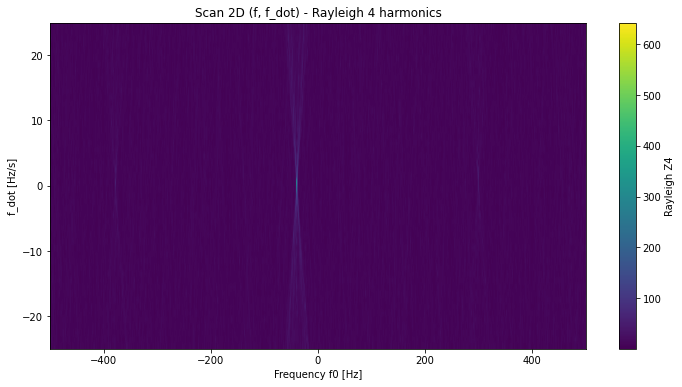

In [7]:
import numpy as np
import matplotlib.pyplot as plt


times = baro_table['TIME']
T = times.max()-times.min()

t0 = (times.max() + times.min())/2
N_photons = len(times)
f0_exp = 9.63935
fdot_exp = -8.8892 * 10**(-12)

df0 = 1/T
dfdot = 2/T**2

f_grid = np.linspace(f0_exp-500*df0, f0_exp+500*df0, 1000)       # frequenze Hz
fdot_grid = np.linspace(fdot_exp-dfdot*25, fdot_exp+dfdot*25, 50)     # Hz/s


def rayleigh_Zn(phases, n_harm=4):
    """
    Calcola il Rayleigh Z_n^2 per un array di fasi [0,1)
    somma su n armoniche
    """
    N = len(phases)
    Z = 0.0
    for k in range(1, n_harm+1):
        C = np.sum(np.cos(2*np.pi*k*phases))
        S = np.sum(np.sin(2*np.pi*k*phases))
        Z += C**2 + S**2
    Z *= 2 / N
    return Z


Z_grid = np.zeros((len(fdot_grid), len(f_grid)))


for i, fdot in enumerate(fdot_grid):
    for j, f0 in enumerate(f_grid):
        phases = ( f0*(times - t0) + 0.5*fdot*(times - t0)**2 ) % 1
        Z_grid[i,j] = rayleigh_Zn(phases, n_harm=4)



#p_grid = np.exp(-Z_grid/2)  # notare che p-value preciso per Z_n² > 1 armonica richiede distribuzione chi² con 2*n_harm df


max_idx = np.unravel_index(np.argmax(Z_grid), Z_grid.shape)
best_fdot = fdot_grid[max_idx[0]]
best_f0 = f_grid[max_idx[1]]
best_Zn = Z_grid[max_idx]

print(f"Punto più significativo:")
print(f"f0 = {best_f0:.8f} Hz")
print(f"fdot = {best_fdot:.3e} Hz/s")
print(f"Z4^2 = {best_Zn:.3f}")
#print(f"p-value (approssimato) = {np.exp(-best_Zn/2):.3e}")


plt.figure(figsize=(12,6))
plt.imshow(Z_grid, origin='lower',
           extent=[-500, 500, -25, 25,],
           aspect='auto', cmap='viridis')
plt.colorbar(label='Rayleigh Z4')
plt.xlabel('Frequency f0 [Hz]')
plt.ylabel('f_dot [Hz/s]')
plt.title('Scan 2D (f, f_dot) - Rayleigh 4 harmonics')
plt.show()

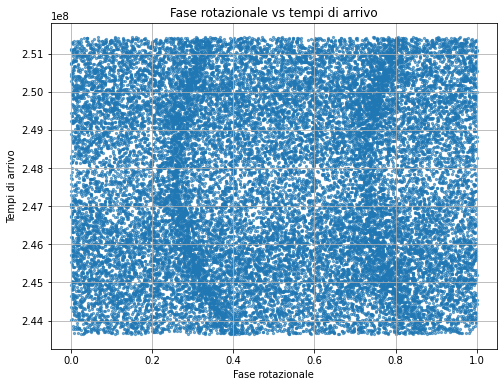

In [8]:
phases_best = ( best_f0*(times - t0) + 0.5*best_fdot*(times - t0)**2 ) % 1
plt.figure(figsize=(8,6))
plt.scatter(phases_best, times, s=5, alpha=0.6)

plt.xlabel('Fase rotazionale')
plt.ylabel('Tempi di arrivo')
plt.title('Fase rotazionale vs tempi di arrivo')

plt.grid(True)
plt.show()

Punto più significativo:
f0 = 9.63934492 Hz
fdot = -8.884e-12 Hz/s
Z4^2 = 1133.011


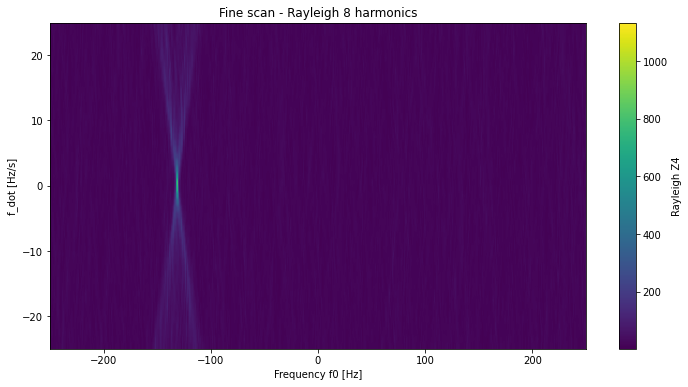

In [9]:
#FINE TUNING

times = baro_table['TIME']
T = times.max()-times.min()

t0 = (times.max() + times.min())/2
N_photons = len(times)
f0_exp = 9.63935
fdot_exp = -8.8892 * 10**(-12)

df0_f = 0.3/T
dfdot_f = 0.6/T**2

f_grid_f = np.linspace(f0_exp-250*df0_f, f0_exp+250*df0_f, 500)       # frequenze Hz
fdot_grid_f = np.linspace(fdot_exp-dfdot_f*25, fdot_exp+dfdot_f*25, 50)     # Hz/s


def rayleigh_Zn(phases, n_harm=8):
    N = len(phases)
    Z = 0.0
    for k in range(1, n_harm+1):
        C = np.sum(np.cos(2*np.pi*k*phases))
        S = np.sum(np.sin(2*np.pi*k*phases))
        Z += C**2 + S**2
    Z *= 2 / N
    return Z


Z_grid_f = np.zeros((len(fdot_grid_f), len(f_grid_f)))


for i, fdot in enumerate(fdot_grid_f):
    for j, f0 in enumerate(f_grid_f):
        phases = ( f0*(times - t0) + 0.5*fdot*(times - t0)**2 ) % 1
        Z_grid_f[i,j] = rayleigh_Zn(phases, n_harm=8)




max_idx = np.unravel_index(np.argmax(Z_grid_f), Z_grid_f.shape)
best_fdot_f = fdot_grid_f[max_idx[0]]
best_f0_f = f_grid_f[max_idx[1]]
best_Zn_f = Z_grid_f[max_idx]

print(f"Punto più significativo:")
print(f"f0 = {best_f0_f:.8f} Hz")
print(f"fdot = {best_fdot_f:.3e} Hz/s")
print(f"Z4^2 = {best_Zn_f:.3f}")



plt.figure(figsize=(12,6))
plt.imshow(Z_grid_f, origin='lower',
           extent=[-250, 250, -25, 25,],
           aspect='auto', cmap='viridis')
plt.colorbar(label='Rayleigh Z4')
plt.xlabel('Frequency f0 [Hz]')
plt.ylabel('f_dot [Hz/s]')
plt.title('Fine scan - Rayleigh 8 harmonics')
plt.show()

Punto più significativo:
f0 = 9.63934492 Hz
fdot = -8.887e-12 Hz/s
Z4^2 = 1313.634


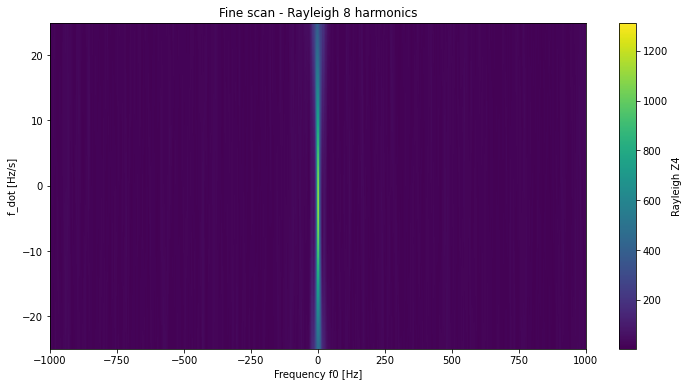

In [10]:
#FINE TUNING

times = baro_table['TIME']
T = times.max()-times.min()

t0 = (times.max() + times.min())/2
N_photons = len(times)
f0_exp = 9.63934492
fdot_exp = -8.884 * 10**(-12)

df0_f = 0.03/T
dfdot_f = 0.06/T**2

f_grid_f = np.linspace(f0_exp-1000*df0_f, f0_exp+1000*df0_f, 2000)       # frequenze Hz
fdot_grid_f = np.linspace(fdot_exp-dfdot_f*25, fdot_exp+dfdot_f*25, 50)     # Hz/s


def rayleigh_Zn(phases, n_harm=8):
    N = len(phases)
    Z = 0.0
    for k in range(1, n_harm+1):
        C = np.sum(np.cos(2*np.pi*k*phases))
        S = np.sum(np.sin(2*np.pi*k*phases))
        Z += C**2 + S**2
    Z *= 2 / N
    return Z


Z_grid_f = np.zeros((len(fdot_grid_f), len(f_grid_f)))


for i, fdot in enumerate(fdot_grid_f):
    for j, f0 in enumerate(f_grid_f):
        phases = ( f0*(times - t0) + 0.5*fdot*(times - t0)**2 ) % 1
        Z_grid_f[i,j] = rayleigh_Zn(phases, n_harm=8)




max_idx = np.unravel_index(np.argmax(Z_grid_f), Z_grid_f.shape)
best_fdot_f = fdot_grid_f[max_idx[0]]
best_f0_f = f_grid_f[max_idx[1]]
best_Zn_f = Z_grid_f[max_idx]

print(f"Punto più significativo:")
print(f"f0 = {best_f0_f:.8f} Hz")
print(f"fdot = {best_fdot_f:.3e} Hz/s")
print(f"Z4^2 = {best_Zn_f:.3f}")



plt.figure(figsize=(12,6))
plt.imshow(Z_grid_f, origin='lower',
           extent=[-1000, 1000, -25, 25,],
           aspect='auto', cmap='viridis')
plt.colorbar(label='Rayleigh Z4')
plt.xlabel('Frequency f0 [Hz]')
plt.ylabel('f_dot [Hz/s]')
plt.title('Fine scan - Rayleigh 8 harmonics')
plt.show()

Punto più significativo:
f0 = 9.63934492 Hz
fdot = -8.88700e-12 Hz/s
Z4^2 = 1313.734


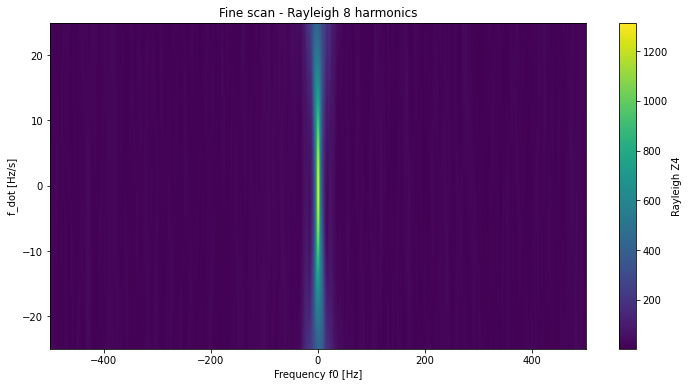

In [11]:
#FINE TUNING pt2

times = baro_table['TIME']
T = times.max()-times.min()

t0 = (times.max() + times.min())/2
N_photons = len(times)
f0_exp = 9.63934492
fdot_exp = -8.88649 * 10**(-12)

df0_f = 0.03/T
dfdot_f = 0.06/T**2

f_grid_f = np.linspace(f0_exp-500*df0_f, f0_exp+500*df0_f, 1000)       # frequenze Hz
fdot_grid_f = np.linspace(fdot_exp-dfdot_f*25, fdot_exp+dfdot_f*25, 50)     # Hz/s


def rayleigh_Zn(phases, n_harm=8):
    N = len(phases)
    Z = 0.0
    for k in range(1, n_harm+1):
        C = np.sum(np.cos(2*np.pi*k*phases))
        S = np.sum(np.sin(2*np.pi*k*phases))
        Z += C**2 + S**2
    Z *= 2 / N
    return Z


Z_grid_f = np.zeros((len(fdot_grid_f), len(f_grid_f)))


for i, fdot in enumerate(fdot_grid_f):
    for j, f0 in enumerate(f_grid_f):
        phases = ( f0*(times - t0) + 0.5*fdot*(times - t0)**2 ) % 1
        Z_grid_f[i,j] = rayleigh_Zn(phases, n_harm=8)




max_idx = np.unravel_index(np.argmax(Z_grid_f), Z_grid_f.shape)
best_fdot_f = fdot_grid_f[max_idx[0]]
best_f0_f = f_grid_f[max_idx[1]]
best_Zn_f = Z_grid_f[max_idx]

print(f"Punto più significativo:")
print(f"f0 = {best_f0_f:.8f} Hz")
print(f"fdot = {best_fdot_f:.5e} Hz/s")
print(f"Z4^2 = {best_Zn_f:.3f}")



plt.figure(figsize=(12,6))
plt.imshow(Z_grid_f, origin='lower',
           extent=[-500, 500, -25, 25,],
           aspect='auto', cmap='viridis')
plt.colorbar(label='Rayleigh Z4')
plt.xlabel('Frequency f0 [Hz]')
plt.ylabel('f_dot [Hz/s]')
plt.title('Fine scan - Rayleigh 8 harmonics')
plt.show()

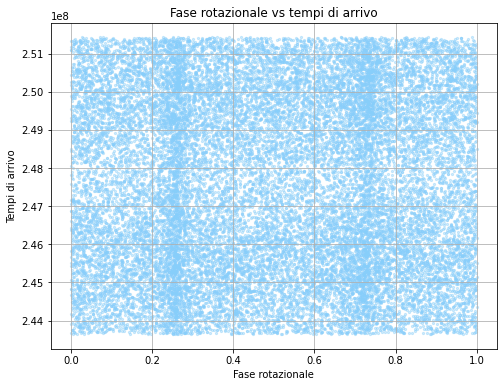

In [12]:
phases_best_f = ( best_f0_f*(times - t0) + 0.5*best_fdot_f*(times - t0)**2 ) % 1
plt.figure(figsize=(8,6))
plt.scatter(phases_best_f, times, s=5, alpha=0.4, color = 'lightskyblue')

plt.xlabel('Fase rotazionale')
plt.ylabel('Tempi di arrivo')
plt.title('Fase rotazionale vs tempi di arrivo')

plt.grid(True)
plt.show()

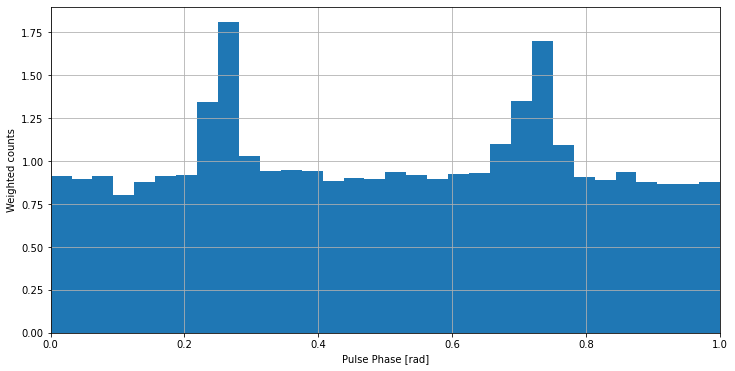

In [13]:
plt.figure(figsize=(12,6))
plt.hist(phases_best_f, bins='auto', density = True, histtype='stepfilled')
plt.xlabel("Pulse Phase [rad]")
plt.ylabel("Weighted counts")
plt.xlim(0,1)
plt.grid()


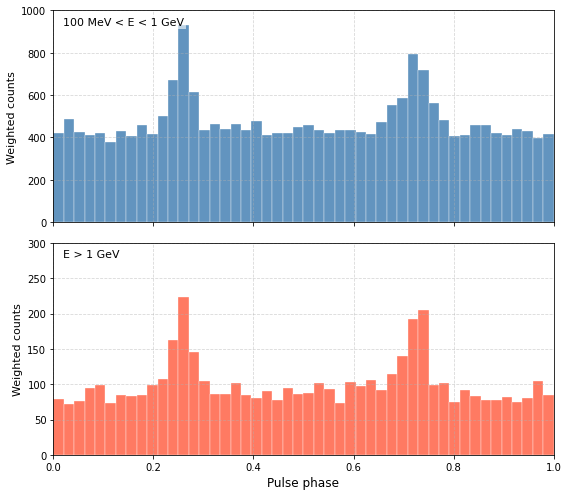

In [14]:

LE_mask = (baro_table['ENERGY'] > 100) & (baro_table['ENERGY'] < 1000)
HE_mask = baro_table['ENERGY'] > 1000

LE = baro_table[LE_mask]
HE = baro_table[HE_mask]

times_HE = HE['TIME']
times_LE = LE['TIME']

phases_HE = ( best_f0_f*(times_HE - t0) + 0.5*best_fdot_f*(times_HE - t0)**2 ) % 1
phases_LE = ( best_f0_f*(times_LE - t0) + 0.5*best_fdot_f*(times_LE - t0)**2 ) % 1


N_BINS = 48 # prova anche 32 o 64

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

for ax, phases, label, color in zip(
    [ax1, ax2],
    [phases_LE, phases_HE],
    ['100 MeV < E < 1 GeV', 'E > 1 GeV'],
    ['steelblue', 'tomato']
):
    ax.hist(phases, bins=N_BINS, range=(0, 1),
            color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.set_ylabel("Weighted counts", fontsize=11)
    ax.set_xlim(0, 1)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.text(0.02, 0.97, label,
            transform=ax.transAxes,
            verticalalignment='top',
            fontsize=11, color='black',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2))
ax1.set_ylim(0, 1000)
ax2.set_ylim(0,300)
ax2.set_xlabel('Pulse phase', fontsize=12)
plt.tight_layout()

In [15]:
best_fdot_f = fdot_grid_f[max_idx[0]]
best_f0_f = f_grid_f[max_idx[1]]
best_Zn_f = Z_grid_f[max_idx]

F = best_f0_f
FDOT = best_fdot_f

P = 1/F

PDOT = -1/(F**2) * FDOT



B = 3.2*10**(19) * np.sqrt(P*PDOT)
print(f"B = {B:.4f} G [Gauss]")

B = 3187544103429.3379 G [Gauss]


In [16]:
tau = P/(2*PDOT)

print(f"Characteristic age of {tau} s")
print(f"Characteriscic age: {tau/(np.pi*10**7)} yrs")

Characteristic age of 542328608350.21094 s
Characteriscic age: 17262.855759816925 yrs


In [17]:
I = 10**45 #g cm^2

O = 2*np.pi /(P)
ODOT = -2*np.pi*PDOT/P**2

dE = I*O*ODOT
print(f"Energy loss due to rotation: dE/dt = {dE:.2e} erg/s")

Energy loss due to rotation: dE/dt = -3.38e+36 erg/s


In [18]:
import numpy as np
np.int = int  # definisce alias temporaneo per compatibilità

In [19]:
from scipy.optimize import minimize

In [20]:
import numpy as np
from scipy.optimize import minimize

# dati
times = baro_table['TIME']
t0 = (times.max() + times.min()) / 2

# funzione Rayleigh
def rayleigh_Zn(phases, n_harm=8):
    N = len(phases)
    Z = 0.0
    for k in range(1, n_harm+1):
        C = np.sum(np.cos(2*np.pi*k*phases))
        S = np.sum(np.sin(2*np.pi*k*phases))
        Z += C**2 + S**2
    Z *= 2 / N
    return Z

# funzione da minimizzare (=-Z)
def neg_Zn(params):
    f0, fdot = params
    
    phases = (f0*(times - t0) + 0.5*fdot*(times - t0)**2) % 1
    Z = rayleigh_Zn(phases, n_harm=8)
    
    return -Z

# punto iniziale: usa il tuo miglior valore dalla griglia
x0 = [best_f0_f, best_fdot_f]

# bounds stretti attorno al massimo trovato
bounds = [
    (best_f0_f - 1e-6, best_f0_f + 1e-6),
    (best_fdot_f - 1e-13, best_fdot_f + 1e-13)
]

# ottimizzazione
result = minimize(
    neg_Zn,
    x0,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 100}
)

# === NUOVI NOMI (OTTIMIZZAZIONE CONTINUA) ===
best_f0_opt = result.x[0]
best_fdot_opt = result.x[1]
best_Zn_opt = -result.fun

# output
print("\n=== RISULTATO OTTIMIZZAZIONE CONTINUA ===")
print(f"f0_opt = {best_f0_opt:.10f} Hz")
print(f"fdot_opt = {best_fdot_opt:.5e} Hz/s")
print(f"Z8^2_opt = {best_Zn_opt:.3f}")


=== RISULTATO OTTIMIZZAZIONE CONTINUA ===
f0_opt = 9.6393449219 Hz
fdot_opt = -8.88700e-12 Hz/s
Z8^2_opt = 1313.734


In [21]:
import numpy as np
from scipy.optimize import minimize

# dati
times = baro_table['TIME']
t0 = (times.max() + times.min()) / 2

# funzione Rayleigh
def rayleigh_Zn(phases, n_harm=6):  # diminuendo armoniche vediamo differenze
    N = len(phases)
    Z = 0.0
    for k in range(1, n_harm+1):
        C = np.sum(np.cos(2*np.pi*k*phases))
        S = np.sum(np.sin(2*np.pi*k*phases))
        Z += C**2 + S**2
    Z *= 2 / N
    return Z

# funzione da minimizzare (=-Z)
def neg_Zn(params):
    f0, fdot = params
    phases = (f0*(times - t0) + 0.5*fdot*(times - t0)**2) % 1
    Z = rayleigh_Zn(phases, n_harm=6)
    return -Z

# punto iniziale: spostato leggermente dal massimo della griglia
x0 = [best_f0_f * 0.9999999, best_fdot_f * 1.0000001]

# bounds più larghi
bounds = [
    (best_f0_f - 5e-6, best_f0_f + 5e-6),
    (best_fdot_f - 5e-13, best_fdot_f + 5e-13)
]

# ottimizzazione
result = minimize(
    neg_Zn,
    x0,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 200}
)

# nuovi nomi variabili ottimizzazione
best_f0_opt2 = result.x[0]
best_fdot_opt2 = result.x[1]
best_Zn_opt2 = -result.fun

print("\n=== RISULTATO OTTIMIZZAZIONE CONTINUA (VARIAZIONE) ===")
print(f"f0_opt2 = {best_f0_opt2:.10f} Hz")
print(f"fdot_opt2 = {best_fdot_opt2:.5e} Hz/s")
print(f"Z6^2_opt2 = {best_Zn_opt2:.3f}")


=== RISULTATO OTTIMIZZAZIONE CONTINUA (VARIAZIONE) ===
f0_opt2 = 9.6393439580 Hz
fdot_opt2 = -8.88700e-12 Hz/s
Z6^2_opt2 = 14.771


In [23]:
import numpy as np
from scipy.optimize import minimize

# dati
times = baro_table['TIME']
t0 = (times.max() + times.min()) / 2

# funzione Rayleigh
def rayleigh_Zn(phases, n_harm=8):  # diminuendo armoniche vediamo differenze
    N = len(phases)
    Z = 0.0
    for k in range(1, n_harm+1):
        C = np.sum(np.cos(2*np.pi*k*phases))
        S = np.sum(np.sin(2*np.pi*k*phases))
        Z += C**2 + S**2
    Z *= 2 / N
    return Z

# funzione da minimizzare (=-Z)
def neg_Zn(params):
    f0, fdot = params
    phases = (f0*(times - t0) + 0.5*fdot*(times - t0)**2) % 1
    Z = rayleigh_Zn(phases, n_harm=6)
    return -Z

# punto iniziale: spostato leggermente dal massimo della griglia
x0 = [best_f0_f, best_fdot_f]

# bounds più larghi
bounds = [
    (best_f0_f - 5e-6, best_f0_f + 5e-6),
    (best_fdot_f - 5e-13, best_fdot_f + 5e-13)
]

# ottimizzazione
result = minimize(
    neg_Zn,
    x0,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 200}
)

# nuovi nomi variabili ottimizzazione
best_f0_opt2 = result.x[0]
best_fdot_opt2 = result.x[1]
best_Zn_opt2 = -result.fun

print("\n=== RISULTATO OTTIMIZZAZIONE CONTINUA (VARIAZIONE) ===")
print(f"f0_opt2 = {best_f0_opt2:.10f} Hz")
print(f"fdot_opt2 = {best_fdot_opt2:.5e} Hz/s")
print(f"Z6^2_opt2 = {best_Zn_opt2:.3f}")


=== RISULTATO OTTIMIZZAZIONE CONTINUA (VARIAZIONE) ===
f0_opt2 = 9.6393449219 Hz
fdot_opt2 = -8.88700e-12 Hz/s
Z6^2_opt2 = 1148.829


In [26]:
import numpy as np
import warnings

# silenzia il warning temporaneo
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    if not hasattr(np, 'bool'):
        np.bool = bool

Peak phases: 0.260, 0.719
Phase lag: 0.458
Amplitude ratio: 0.760
Amplitude ratio non corretto: 0.854


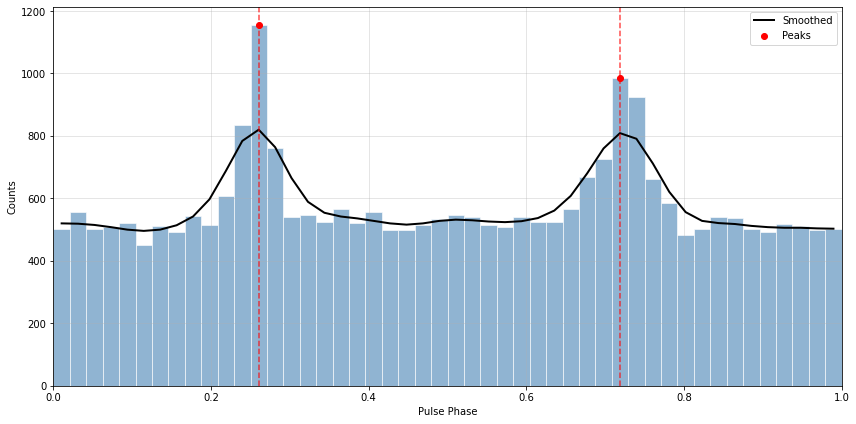

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

# =========================
# 1. Histogram
# =========================
N_BINS = 48

counts, bin_edges = np.histogram(phases_best_f, bins=N_BINS, range=(0,1))
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# =========================
# 2. Smooth (riduce rumore)
# =========================
counts_smooth = gaussian_filter1d(counts, sigma=1.5)

# =========================
# 3. Find peaks
# =========================
peaks, _ = find_peaks(counts_smooth, distance=len(counts)//4)

# prendi i due più alti
sorted_idx = np.argsort(counts_smooth[peaks])[::-1]
top2 = peaks[sorted_idx[:2]]

# =========================
# 4. Phase lag
# =========================
p1, p2 = bin_centers[top2]
phase_lag = np.abs(p2 - p1)

# wrap-around
if phase_lag > 0.5:
    phase_lag = 1 - phase_lag

# =========================
# 5. Amplitude ratio
# =========================
A1, A2 = counts[top2]

# stima background (semplice)
background = np.min(counts)

A1_corr = A1 - background
A2_corr = A2 - background

amplitude_ratio = A2_corr / A1_corr

A1_nc = A1
A2_nc = A2

amplitude_ratio_nc = A2_nc / A1_nc
# =========================
# 6. Print risultati
# =========================
print(f"Peak phases: {p1:.3f}, {p2:.3f}")
print(f"Phase lag: {phase_lag:.3f}")
print(f"Amplitude ratio: {amplitude_ratio:.3f}")
print(f"Amplitude ratio non corretto: {amplitude_ratio_nc:.3f}")
# =========================
# 7. Plot
# =========================
plt.figure(figsize=(12,6))

# istogramma
plt.hist(phases_best_f, bins=N_BINS, range=(0,1),
         alpha=0.6, color='steelblue', edgecolor='white')

# curva smooth
plt.plot(bin_centers, counts_smooth, color='black', lw=2, label='Smoothed')

# picchi
plt.scatter(bin_centers[top2], counts[top2],
            color='red', zorder=3, label='Peaks')

# linee verticali
for p in bin_centers[top2]:
    plt.axvline(p, linestyle='--', color='red', alpha=0.7)

plt.xlabel("Pulse Phase")
plt.ylabel("Counts")
plt.xlim(0,1)
plt.grid(alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

Peak phases: 0.260, 0.719
Phase lag: 0.458
Amplitude ratio: 0.760
Amplitude ratio non corretto: 0.854


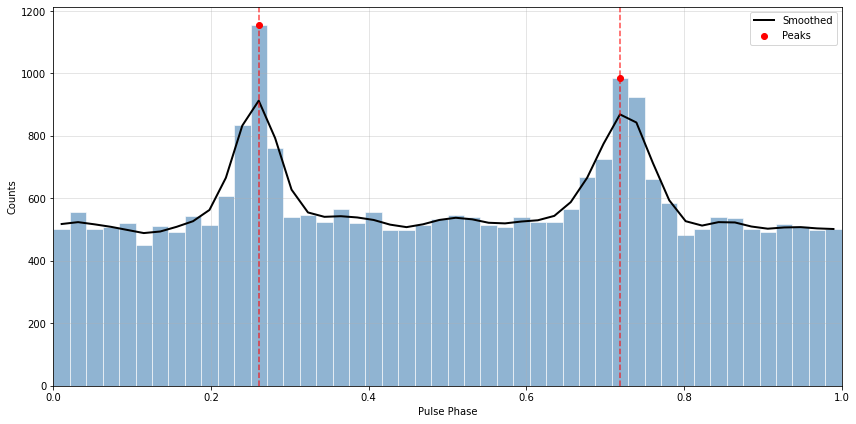

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

# =========================
# 1. Histogram
# =========================
N_BINS = 48

counts, bin_edges = np.histogram(phases_best_f, bins=N_BINS, range=(0,1))
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# =========================
# 2. Smooth (riduce rumore)
# =========================
counts_smooth = gaussian_filter1d(counts, sigma=1)

# =========================
# 3. Find peaks
# =========================
peaks, _ = find_peaks(counts_smooth, distance=len(counts)//4)

# prendi i due più alti
sorted_idx = np.argsort(counts_smooth[peaks])[::-1]
top2 = peaks[sorted_idx[:2]]

# =========================
# 4. Phase lag
# =========================
p1, p2 = bin_centers[top2]
phase_lag = np.abs(p2 - p1)

# wrap-around
if phase_lag > 0.5:
    phase_lag = 1 - phase_lag

# =========================
# 5. Amplitude ratio
# =========================
A1, A2 = counts[top2]

# stima background (semplice)
background = np.min(counts)

A1_corr = A1 - background
A2_corr = A2 - background

amplitude_ratio = A2_corr / A1_corr

A1_nc = A1
A2_nc = A2

amplitude_ratio_nc = A2_nc / A1_nc
# =========================
# 6. Print risultati
# =========================
print(f"Peak phases: {p1:.3f}, {p2:.3f}")
print(f"Phase lag: {phase_lag:.3f}")
print(f"Amplitude ratio: {amplitude_ratio:.3f}")
print(f"Amplitude ratio non corretto: {amplitude_ratio_nc:.3f}")
# =========================
# 7. Plot
# =========================
plt.figure(figsize=(12,6))

# istogramma
plt.hist(phases_best_f, bins=N_BINS, range=(0,1),
         alpha=0.6, color='steelblue', edgecolor='white')

# curva smooth
plt.plot(bin_centers, counts_smooth, color='black', lw=2, label='Smoothed')

# picchi
plt.scatter(bin_centers[top2], counts[top2],
            color='red', zorder=3, label='Peaks')

# linee verticali
for p in bin_centers[top2]:
    plt.axvline(p, linestyle='--', color='red', alpha=0.7)

plt.xlabel("Pulse Phase")
plt.ylabel("Counts")
plt.xlim(0,1)
plt.grid(alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

Original phase lag: 0.458
Original amplitude ratio: 0.760
Phase lag = 0.458 ± 0.00093
Amplitude ratio = 0.760 ± 0.240


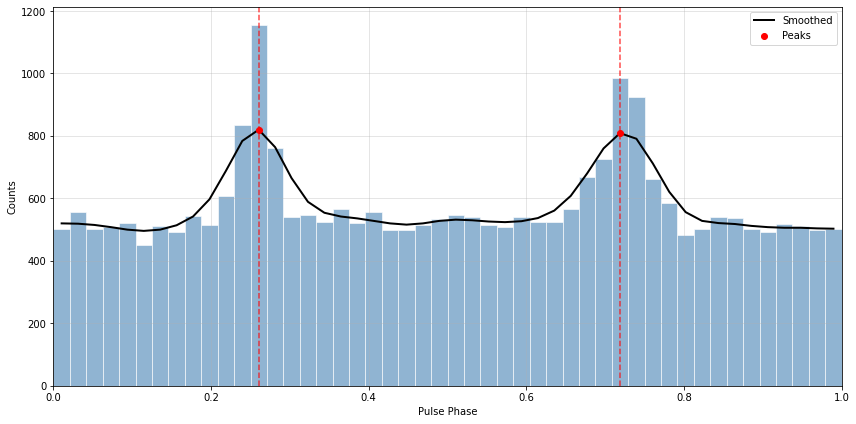